In [1]:
import torch
import timm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

e:\Tensorflow Kernel\tensorflow_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
num_classes = 8   # same as training

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=num_classes
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(torch.load("path_to/pretrained_vit_fer_model.pth"))
model = model.to(device)

In [4]:
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
test_dataset = datasets.ImageFolder(
    "path_to/AffectNet/Test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes
print("Classes:", class_names)

Classes: ['Anger', 'Contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [11]:
y_true = []
y_pred = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [12]:
cm = confusion_matrix(y_true, y_pred)

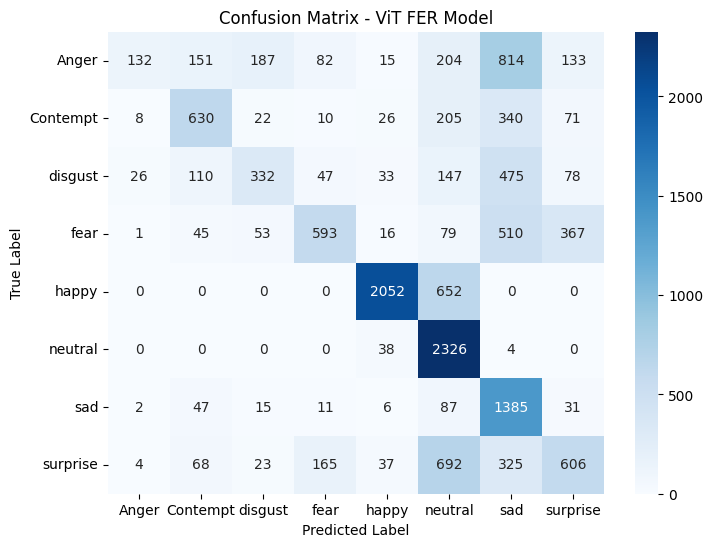

In [ ]:
#Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ViT FER Model")

plt.show()

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       Anger       0.76      0.08      0.14      1718
    Contempt       0.60      0.48      0.53      1312
     disgust       0.53      0.27      0.35      1248
        fear       0.65      0.36      0.46      1664
       happy       0.92      0.76      0.83      2704
     neutral       0.53      0.98      0.69      2368
         sad       0.36      0.87      0.51      1584
    surprise       0.47      0.32      0.38      1920

    accuracy                           0.55     14518
   macro avg       0.60      0.51      0.49     14518
weighted avg       0.62      0.55      0.52     14518



In [7]:
#Attention Heatmap
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

device = next(model.parameters()).device


def visualize_attention(image_path):

    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    # Forward to get features
    with torch.no_grad():
        x = model.patch_embed(img_tensor)
        cls_token = model.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + model.pos_embed
        x = model.pos_drop(x)

        for blk in model.blocks[:-1]:
            x = blk(x)

        # last block attention
        blk = model.blocks[-1]
        B, N, C = x.shape

        qkv = blk.attn.qkv(x)
        qkv = qkv.reshape(B, N, 3, blk.attn.num_heads, C // blk.attn.num_heads)
        qkv = qkv.permute(2,0,3,1,4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2,-1)) * blk.attn.scale
        attn = attn.softmax(dim=-1)

    # Average attention heads
    attn = attn.mean(dim=1)

    cls_attn = attn[0,0,1:]

    grid_size = int(np.sqrt(cls_attn.shape[0]))

    attn_map = cls_attn.reshape(grid_size,grid_size).cpu().numpy()

    attn_map = (attn_map - attn_map.min())/(attn_map.max()-attn_map.min())

    heatmap = cv2.resize(attn_map,(224,224))
    heatmap = cv2.applyColorMap(np.uint8(255*heatmap),cv2.COLORMAP_JET)

    img = cv2.imread(image_path)
    img = cv2.resize(img,(224,224))

    overlay = cv2.addWeighted(img,0.6,heatmap,0.4,0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(attn_map,cmap="jet")
    plt.title("Attention Map")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

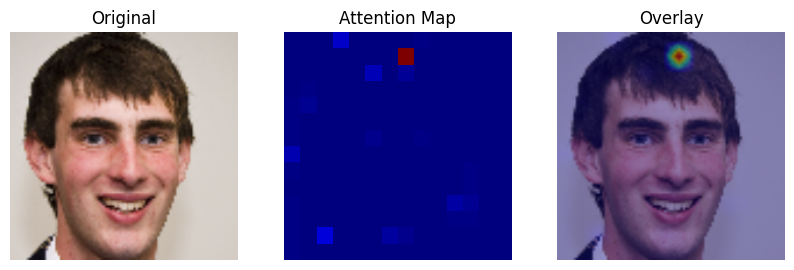

In [ ]:
visualize_attention("path_to/image1.png" )

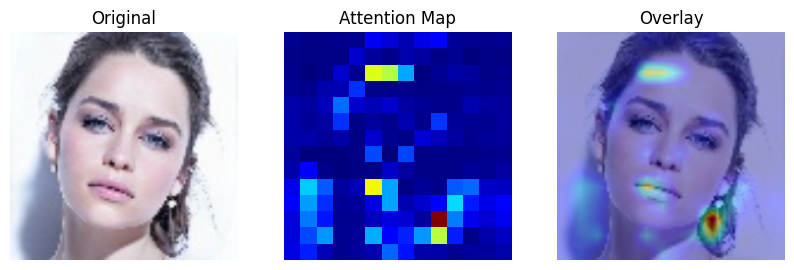

In [ ]:
visualize_attention("path_to/image2.jpg")

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

features = []
labels_list = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        # extract transformer features
        outputs = model.forward_features(images)

        outputs = outputs[:,0,:]   # CLS token

        features.append(outputs.cpu().numpy())
        labels_list.append(labels.numpy())

In [27]:
features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

print("Feature shape:", features.shape)

Feature shape: (14518, 768)


In [28]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

features_2d = tsne.fit_transform(features)

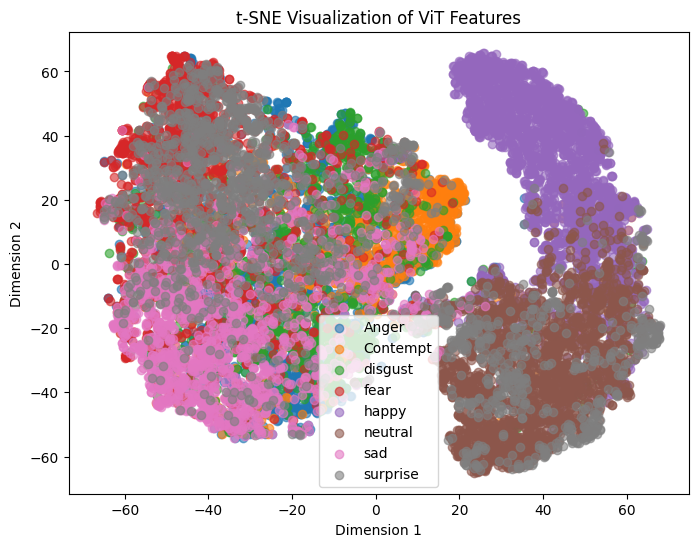

In [29]:
plt.figure(figsize=(8,6))

for i, label in enumerate(class_names):

    idx = labels_list == i

    plt.scatter(
        features_2d[idx,0],
        features_2d[idx,1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Visualization of ViT Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()